# 01 Data Exploration — Constraint-Datensätze

**PA1 ZHAW IUNR** | Bächler, Hofstetter, Reichlin | Betreuer: Patrick Laube

Qualitätsprüfung der Datensätze, die für die **Ausschlussmasken** (02a) benötigt werden.
WLC-Datensätze (Solar, Schnee, Stromnetz, Akzeptanz) werden erst in 03 geprüft.

**Input:**
```
data/raw/dem/                      DEM (DHM25)
data/raw/permafrost/               Permafrost-Hinweiskarte
data/raw/tlm3d/                    swissTLM3D (Bodenbedeckung, Gewässer, Gebäude)
data/raw/hazards/                  Naturereigniskataster GR
data/raw/protected_areas/          Schutzgebiete (BLN, AULAV, UNESCO)
data/raw/swissboundaries/          Kantonsgrenze GR
```

**Output:** Qualitätsreport → weiter mit `02Constraints_Mask.ipynb` → `constraint_mask_s2.tif`

## 1. Setup & Imports

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
import fiona
import warnings
warnings.filterwarnings("ignore")                                          # Warnungen unterdrücken

# --- Darstellungsoptionen ---
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.titlesize": 11})

# --- Pfade ---
RAW = Path("../data/raw")                                                 # Rohdaten
OUT = Path("../outputs/figures")                                           # Figuren-Output
OUT.mkdir(parents=True, exist_ok=True)

print("✓ Setup OK")

✓ Setup OK


## 2. Kantonsgrenze GR

In [2]:
print("=== Kantonsgrenze GR ===\n")

# --- Gemeindedaten laden ---
municipalities = gpd.read_file(RAW / "swissboundaries/swissboundaries_gemeinden.shp")
canton_col = next(c for c in municipalities.columns if "KANT" in c.upper() or c.upper().startswith("KT"))  # Kantonsspalte
name_col = next(c for c in municipalities.columns if "NAME" in c.upper())                                   # Namenspalte

# --- Graubünden filtern & zu einem Polygon auflösen ---
gr_muni = municipalities[municipalities[canton_col] == 18.0].copy()        # Kanton GR = 18
gr_border = gpd.GeoDataFrame(
    {"geometry": [gr_muni.unary_union]},                                   # Union aller Gemeinden
    crs=gr_muni.crs
)

print(f"GR: {len(gr_muni)} Gemeinden | {gr_border.area.sum()/1e6:.0f} km² | CRS: {gr_muni.crs}")

=== Kantonsgrenze GR ===

GR: 100 Gemeinden | 7105 km² | CRS: EPSG:2056


## 3. Übersichtstabelle — Raster-Datensätze

In [3]:
summary = []

def check_raster(name, path):
    """Prüft ein Raster und fügt Statistik zur Übersichtstabelle hinzu."""
    tifs = sorted(path.glob("*.tif"))[:1]                                  # erstes .tif suchen
    if not tifs:
        summary.append({"Datensatz": name, "Datei": "FEHLT", "CRS OK": "—"})
        return
    with rasterio.open(tifs[0]) as src:
        d = src.read(1, masked=True)                                       # Band 1 lesen (masked)
        v = d.compressed()                                                 # nur gültige Pixel
        summary.append({
            "Datensatz": name, "Datei": tifs[0].name,
            "CRS": str(src.crs), "Aufl.": f"{src.res[0]:.0f}m",
            "Min": f"{v.min():.1f}" if v.size else "—",
            "Max": f"{v.max():.1f}" if v.size else "—",
            "NoData%": f"{d.mask.sum()/d.size*100:.1f}",
            "CRS OK": "✓" if src.crs.to_epsg() == 2056 else "✗"           # Soll-CRS: LV95
        })

# --- Raster prüfen ---
check_raster("DHM25", RAW / "dem")
check_raster("Permafrost", RAW / "permafrost")

# --- Tabelle anzeigen ---
df_summary = pd.DataFrame(summary).fillna("—")
df_summary.style.map(
    lambda v: "background:#f8cecc" if v == "✗" else ("background:#d5e8d4" if v == "✓" else ""),
    subset=["CRS OK"]
)

,Datensatz,Datei,CRS OK,CRS,Aufl.,Min,Max,NoData%
0,DHM25,FEHLT,—,—,—,—,—,—
1,Permafrost,permafrost_2056.tif,✓,EPSG:2056,25m,0.0,5.0,96.4


## 4. swissTLM3D — Layer-Inventar

In [4]:
print("=== swissTLM3D — Layer-Inventar ===\n")

# --- GPKG-Pfad bestimmen (kann Verzeichnis sein) ---
tlm_path = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"
if tlm_path.is_dir():                                                      # .gpkg-Ordner → inneres .gpkg
    tlm_path = next(tlm_path.glob("*.gpkg"))

# --- Alle Layer auflisten ---
layers = fiona.listlayers(str(tlm_path))
constraint_layers = {                                                      # für Constraints relevante Layer
    "tlm_bb_bodenbedeckung", "tlm_gewaesser_fliessgewaesser",
    "tlm_gewaesser_stehendes_gewaesser", "tlm_bauten_gebaeude_footprint"
}

tlm_info = []
for lyr in layers:
    with fiona.open(str(tlm_path), layer=lyr) as src:
        tlm_info.append({
            "Layer": lyr, "Features": len(src),
            "Geometrie": src.schema["geometry"],
            "Constraint": "✓" if lyr in constraint_layers else ""
        })

pd.DataFrame(tlm_info).style.map(
    lambda v: "font-weight:bold" if v == "✓" else "", subset=["Constraint"]
)

=== swissTLM3D — Layer-Inventar ===



,Layer,Features,Geometrie,Constraint
0,tlm_areale_nutzungsareal,36368,3D Polygon,
1,tlm_areale_freizeitareal,3400,3D Polygon,
2,tlm_areale_verkehrsareal,15167,3D Polygon,
3,tlm_areale_schutzgebiet,2,3D Polygon,
4,tlm_bauten_gebaeude_footprint,4125163,3D Polygon,✓
5,tlm_bauten_sportbaute_lin,3160,3D LineString,
6,tlm_bauten_sportbaute_ply,16641,3D Polygon,
7,tlm_bauten_staubaute,73219,3D Polygon,
8,tlm_bauten_verbauung,83109,3D LineString,
9,tlm_bauten_verkehrsbaute_lin,1966,3D LineString,


## 5. Bodenbedeckung — Wald, Gletscher, Siedlung

In [5]:
print("=== Bodenbedeckung — Wald, Gletscher, Siedlung ===\n")

# --- Bodenbedeckungs-Layer laden und auf GR clippen ---
bb_layer = next(lyr for lyr in fiona.listlayers(str(tlm_path)) if "bodenbedeckung" in lyr.lower())
bodenbedeckung = gpd.read_file(str(tlm_path), layer=bb_layer)
bodenbedeckung = gpd.clip(bodenbedeckung, gr_border.to_crs(bodenbedeckung.crs))   # auf GR zuschneiden
cat_col = next(c for c in bodenbedeckung.columns if "art" in c.lower() or "klasse" in c.lower())  # Kategorie-Spalte

print(f"Layer: {bb_layer} | Spalte: {cat_col} | Features: {len(bodenbedeckung)}\n")

# --- Pro Kategorie: Anzahl und Fläche ---
for cat, group in bodenbedeckung.groupby(cat_col):
    print(f"  {str(cat):30s} {len(group):>6d} Features  {group.area.sum()/1e6:>8.1f} km²")

=== Bodenbedeckung — Wald, Gletscher, Siedlung ===

Layer: tlm_bb_bodenbedeckung | Spalte: objektart | Features: 210698

  Fels                            67353 Features     822.6 km²
  Fels locker                     13342 Features      75.7 km²
  Felsbloecke                       930 Features       8.1 km²
  Felsbloecke locker                357 Features       2.7 km²
  Feuchtgebiet                     4447 Features      37.7 km²
  Fliessgewaesser                   140 Features      15.2 km²
  Gebueschwald                    11875 Features     197.6 km²
  Gehoelzflaeche                  26261 Features      17.1 km²
  Gletscher                         424 Features      88.7 km²
  Lockergestein                   45159 Features    1212.7 km²
  Lockergestein locker            15251 Features     137.4 km²
  Schneefeld Toteis                 876 Features       4.6 km²
  Stehende Gewaesser               3594 Features      32.9 km²
  Wald                            15409 Features    1614.8 k

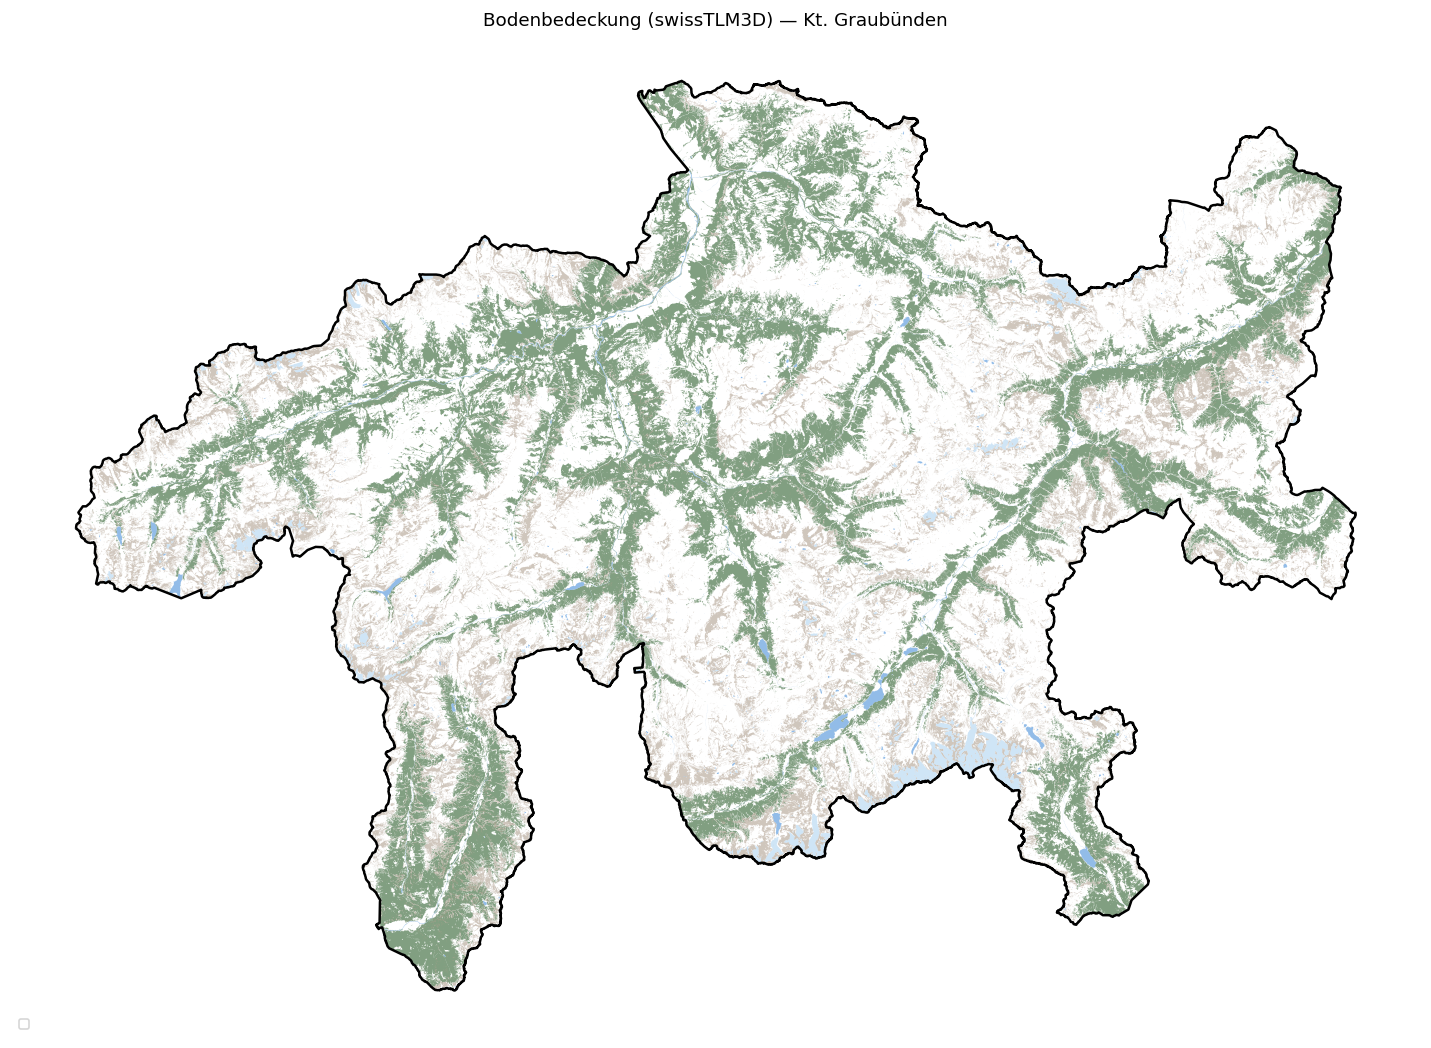

In [6]:
# --- Bodenbedeckungskarte ---
fig, ax = plt.subplots(figsize=(12, 10))
gr_border.boundary.plot(ax=ax, color="black", linewidth=1.5)               # Kantonsgrenze zeichnen

colors = {"Wald": "#2D5F2D", "Fels": "#B0A090", "Gletscher": "#B0D4F1",
          "Gewaesser": "#4A90D9", "Gebaeude": "#D45050"}

for key, color in colors.items():
    sub = bodenbedeckung[bodenbedeckung[cat_col].str.contains(key, case=False, na=False)]
    if not sub.empty:
        sub.plot(ax=ax, color=color, alpha=0.6, label=key)                 # Kategorie einfärben

ax.legend(loc="lower left", fontsize=8)
ax.set_title("Bodenbedeckung (swissTLM3D) — Kt. Graubünden")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(OUT / "bodenbedeckung_gr.png", dpi=150, bbox_inches="tight")   # Export

## 6. DEM — Höhenverteilung und Ableitungen

=== DEM — Höhenverteilung und Ableitungen ===

DEM: 255–4043 m | 25m | (4011, 5642)
  1500–2700 m             5008 km² (70.5%)
  Slope < 35°             5205 km² (73.3%)
  Aspect 120–240°         2315 km² (32.6%)


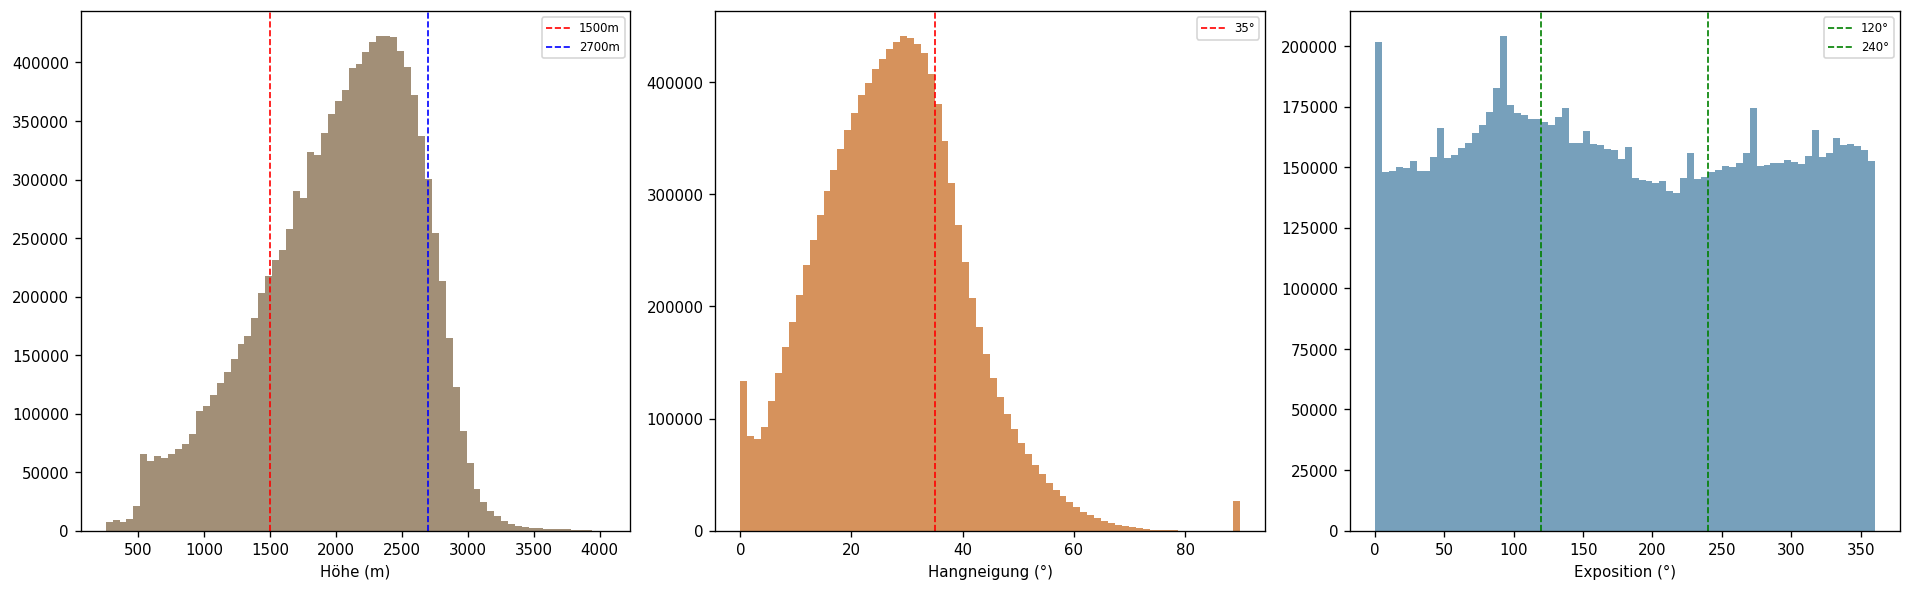

In [7]:
print("=== DEM — Höhenverteilung und Ableitungen ===\n")

# --- DEM-Datei suchen (.tif oder .asc) ---
dem_path = next((RAW / "dem").glob("*.tif"), None)
if not dem_path:
    dem_path = next((RAW / "dem").glob("**/*.asc"), None)
if not dem_path:
    raise FileNotFoundError("Kein DEM in data/raw/dem/")

# --- DEM auf GR clippen ---
with rasterio.open(dem_path) as src:
    gr_clip = gr_border.to_crs(src.crs) if src.crs and src.crs != gr_border.crs else gr_border
    dem, dem_tf = mask(src, [gr_clip.geometry.iloc[0].__geo_interface__], crop=True, nodata=src.nodata)
    dem = dem[0].astype(float)                                             # erstes Band extrahieren
    valid = np.isfinite(dem) & ((dem != src.nodata) if src.nodata else np.ones_like(dem, dtype=bool))
    px_area = src.res[0] * src.res[1] / 1e6                               # Pixelfläche in km²

# --- Slope & Aspect berechnen (finite-difference) ---
dem_v = dem[valid]                                                         # nur gültige Pixel
dy, dx = np.gradient(dem, src.res[0])                                      # Höhengradient
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))                      # Hangneigung [°]
aspect = np.degrees(np.arctan2(-dx, dy)) % 360                             # Exposition [0–360°]
print(f"DEM: {dem_v.min():.0f}–{dem_v.max():.0f} m | {src.res[0]:.0f}m | {dem.shape}")

# --- Histogramme: Höhe, Slope, Aspect ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, lbl, col, vlines in [
    (axes[0], dem_v, "Höhe (m)", "#8B7355", [(1500, "r", "1500m"), (2700, "b", "2700m")]),
    (axes[1], slope[valid], "Hangneigung (°)", "#CC7733", [(35, "r", "35°")]),
    (axes[2], aspect[valid], "Exposition (°)", "#5588AA", [(120, "g", "120°"), (240, "g", "240°")]),
]:
    ax.hist(data, bins=72, color=col, edgecolor="none", alpha=0.8)         # Histogramm
    for v, c, l in vlines:
        ax.axvline(v, color=c, ls="--", lw=1, label=l)                    # Schwellenwerte
    ax.set_xlabel(lbl)
    ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(OUT / "dem_analyse_gr.png", dpi=150, bbox_inches="tight")

# --- Flächenstatistik ---
for label, count in [
    ("1500–2700 m", ((dem_v >= 1500) & (dem_v <= 2700)).sum()),
    ("Slope < 35°", (slope[valid] < 35).sum()),
    ("Aspect 120–240°", ((aspect[valid] >= 120) & (aspect[valid] <= 240)).sum()),
]:
    print(f"  {label:20s} {count*px_area:>7.0f} km² ({count/dem_v.size*100:.1f}%)")

## 7. Permafrost-Hinweiskarte

In [8]:
print("=== Permafrost-Hinweiskarte ===\n")

pf_path = next((RAW / "permafrost").glob("*.tif"), None)
if not pf_path:
    print("⚠ Permafrost nicht gefunden")
else:
    with rasterio.open(pf_path) as src:
        v = src.read(1, masked=True).compressed()                          # gültige Pixel extrahieren
    print(f"CRS: {src.crs} | {src.res[0]:.0f}m | Werte: {v.min():.0f}–{v.max():.0f}")
    if v.min() > 1000:                                                     # Höhenwerte → Untergrenze
        print(f"→ Höhenwerte (Permafrost-Untergrenze). Ausschluss: DEM ≥ Wert")
    elif len(np.unique(v)) <= 10:                                          # wenige Werte → Klassen
        print(f"→ Klassen: {np.unique(v)}")
    else:                                                                  # kontinuierlich
        print(f"→ {len(np.unique(v))} einzigartige Werte (kontinuierlich)")

=== Permafrost-Hinweiskarte ===

CRS: EPSG:2056 | 25m | Werte: 0–5
→ Klassen: [0 1 2 3 4 5]


## 8. Naturgefahren (Geodienste.ch)

In [9]:
print("=== Naturgefahren (Geodienste.ch) ===\n")

# --- Pfade und Gefahrentypen ---
hazard_base = RAW / "hazards/naturereigniskataster_v1_0_GR_csv_lv95(1)/csv/naturereigniskataster_v1_0"
hazard_csvs = {
    "Lawinen": "prozessraum_lawine.csv",
    "Sturz": "prozessraum_sturz.csv",
    "Rutschung": "prozessraum_rutschung.csv",
    "Hochwasser": "prozessraum_wasser_ueberschwemmung_uebermurung.csv",
}

# --- Basis-Geometrien (E/N-Koordinaten) ---
df_basis = pd.read_csv(
    hazard_base / "basisinformation.csv", sep=";",
    usecols=["primaerschluessel_bi_id", "E", "N"]
)
print(f"Basis-Geometrien: {len(df_basis)}\n")

# --- Gefahrentypen joinen und zusammenfassen ---
hazard_info = []
for label, filename in hazard_csvs.items():
    csv_path = hazard_base / filename
    if not csv_path.exists():
        continue
    df_h = pd.read_csv(csv_path, sep=";")                                 # Gefahrendaten laden
    fk_col = next((c for c in df_h.columns if "fremdschluessel_bi_id" in c.lower()), None)
    merged = df_h.merge(df_basis, left_on=fk_col, right_on="primaerschluessel_bi_id", how="left") if fk_col else df_h
    n_geom = merged[["E", "N"]].notna().all(axis=1).sum() if fk_col else 0  # mit Koordinaten
    hazard_info.append({"Typ": label, "Datei": filename, "Einträge": len(df_h), "Mit Geom": n_geom})
    print(f"{label}: {len(df_h)} Einträge, {n_geom} mit E/N")

pd.DataFrame(hazard_info)

=== Naturgefahren (Geodienste.ch) ===

Basis-Geometrien: 17302

Lawinen: 11454 Einträge, 11454 mit E/N
Sturz: 3155 Einträge, 3155 mit E/N
Rutschung: 2050 Einträge, 2050 mit E/N
Hochwasser: 2241 Einträge, 2241 mit E/N


,Typ,Datei,Einträge,Mit Geom
0,Lawinen,prozessraum_lawine.csv,11454,11454
1,Sturz,prozessraum_sturz.csv,3155,3155
2,Rutschung,prozessraum_rutschung.csv,2050,2050
3,Hochwasser,prozessraum_wasser_ueberschwemmung_uebermurung...,2241,2241


## 9. Schutzgebiete (BAFU)

In [10]:
print("=== Schutzgebiete (BAFU) ===\n")

# --- Schutzgebiet-Shapefiles ---
protected_files = {
    "BLN": RAW / "protected_areas/bundesinventare-bln_2056.shp",
    "AULAV": RAW / "protected_areas/schutzgebiete-aulav_2056.shp",
    "Biosphärenreservate": RAW / "protected_areas/schutzgebiete-biosphaerenreservate_2056.shp",
    "UNESCO": RAW / "protected_areas/unesco-weltnaturerbe_2056.shp",
}

schutz_info = []
for label, fpath in protected_files.items():
    if not fpath.exists():                                                 # Datei fehlt
        schutz_info.append({"Typ": label, "Datei": "FEHLT", "Features": 0})
        continue
    gdf = gpd.read_file(fpath)                                            # Schutzgebiet laden
    gdf_gr = gpd.clip(gdf.to_crs(gr_border.crs), gr_border)              # auf GR clippen
    area = gdf_gr.area.sum() / 1e6                                        # Fläche in km²
    schutz_info.append({
        "Typ": label, "Datei": fpath.name, "Features": len(gdf),
        "Features GR": len(gdf_gr), "Fläche GR (km²)": f"{area:.1f}"
    })
    print(f"{label}: {len(gdf_gr)} Features in GR, {area:.1f} km²")

pd.DataFrame(schutz_info)

=== Schutzgebiete (BAFU) ===

BLN: 18 Features in GR, 1283.9 km²
AULAV: 74 Features in GR, 64.6 km²
Biosphärenreservate: 3 Features in GR, 448.7 km²
UNESCO: 1 Features in GR, 45.6 km²


,Typ,Datei,Features,Features GR,Fläche GR (km²)
0,BLN,bundesinventare-bln_2056.shp,174,18,1283.9
1,AULAV,schutzgebiete-aulav_2056.shp,326,74,64.6
2,Biosphärenreservate,schutzgebiete-biosphaerenreservate_2056.shp,6,3,448.7
3,UNESCO,unesco-weltnaturerbe_2056.shp,8,1,45.6


## 10. MCE-Übersicht — Alle Constraint-Datensätze

In [ ]:
print("=== MCE-Übersicht: Constraint-Datensätze für Preprocessing ===\n")

# --- Hilfsfunktionen ---
def _ok(p):                                                                # Existenzprüfung ✓/✗
    return "✓" if (p is not None and Path(p).exists()) else "✗"

def _res(p):                                                               # Rasterauflösung auslesen
    if p and Path(p).exists():
        with rasterio.open(p) as ds:
            return f"{ds.res[0]:.0f} m"
    return "—"

# --- Metadaten aus vorherigen Zellen dynamisch auslesen ---
_dem_res = _res(dem_path)                                                  # DEM-Auflösung (Zelle 6)
_pf_res  = _res(pf_path) if pf_path else "—"                              # Permafrost-Aufl. (Zelle 7)
_aulav   = protected_files["AULAV"]                                        # AULAV-Pfad (Zelle 9)
_aulav_shps = sorted(_aulav.glob("*.shp")) if _aulav.is_dir() else []     # Sublayer-Shapefiles
_tlm_constraint = ["tlm_bb_bodenbedeckung", "tlm_gewaesser_fliessgewaesser",
                    "tlm_gewaesser_stehendes_gewaesser", "tlm_bauten_gebaeude_footprint"]
_tlm_ok = [l for l in _tlm_constraint if l in layers]                      # vorhandene TLM3D-Layer

print(f"  DEM:            {dem_path.name} ({_dem_res})")
print(f"  Permafrost:     {pf_path.name if pf_path else '—'} ({_pf_res})")
print(f"  TLM3D:          {tlm_path.name} ({len(_tlm_ok)}/{len(_tlm_constraint)} Constraint-Layer)")
print(f"  AULAV:          {_aulav.name} ({len(_aulav_shps)} Sublayer-Shapefiles)")
print(f"  BLN:            {protected_files['BLN'].name}")
print(f"  Biosphärenres.: {protected_files['Biosphärenreservate'].name}")
print(f"  UNESCO:         {protected_files['UNESCO'].name}")
print(f"  Naturgefahren:  {len(hazard_csvs)} CSVs ({hazard_base.parent.name})\n")

# --- Alle 20 Ausschlusskriterien (IDs gemäss 02-Notebook) ---
mce = pd.DataFrame([
    {"ID": "C01", "Code": "c01_elev_min",        "Kategorie": "Topographie",   "Kriterium": "Höhe Untergrenze",                       "Datenquelle": f"DHM25 ({dem_path.name})",                                                  "Format": "Raster",      "Aufl.": _dem_res, "S2": "≥ 1500 m",                      "✓": _ok(dem_path)},
    {"ID": "C02", "Code": "c02_elev_max",        "Kategorie": "Topographie",   "Kriterium": "Höhe Obergrenze",                        "Datenquelle": f"DHM25 ({dem_path.name})",                                                  "Format": "Raster",      "Aufl.": _dem_res, "S2": "≤ 2700 m",                      "✓": _ok(dem_path)},
    {"ID": "C03", "Code": "c03_slope",           "Kategorie": "Topographie",   "Kriterium": "Hangneigung",                            "Datenquelle": f"DHM25 (abgeleitet, {dem_path.name})",                                      "Format": "Raster",      "Aufl.": _dem_res, "S2": "< 35°",                         "✓": _ok(dem_path)},
    {"ID": "C04", "Code": "c04_aspect",          "Kategorie": "Topographie",   "Kriterium": "Exposition (Nordhänge)",                  "Datenquelle": f"DHM25 (abgeleitet, {dem_path.name})",                                      "Format": "Raster",      "Aufl.": _dem_res, "S2": "Ausschluss ausserh. 120°–240°", "✓": _ok(dem_path)},
    {"ID": "C05", "Code": "c05_permafrost",      "Kategorie": "Topographie",   "Kriterium": "Permafrost (Hinweiskarte)",               "Datenquelle": f"BAFU Permafrost ({pf_path.name if pf_path else '—'})",                     "Format": "Raster",      "Aufl.": _pf_res,  "S2": "Ausschluss > Klasse 3",         "✓": _ok(pf_path)},
    {"ID": "C06", "Code": "c06_moorlandschaften","Kategorie": "Naturschutz",   "Kriterium": "Moorlandschaften",                        "Datenquelle": f"AULAV ({_aulav.name}, AulavMoorlandschaft)",                                "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(_aulav)},
    {"ID": "C07", "Code": "c07_biotope",         "Kategorie": "Naturschutz",   "Kriterium": "Biotope (Auen + Hoch-/Flachmoore)",       "Datenquelle": f"AULAV ({_aulav.name}, Auen + UebrigeSchutzgebiete)",                        "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(_aulav)},
    {"ID": "C08", "Code": "c08_vogelreservate",  "Kategorie": "Naturschutz",   "Kriterium": "Wasser- und Zugvogelreservate",           "Datenquelle": f"AULAV ({_aulav.name}, UebrigeSchutzgebiete)",                               "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(_aulav)},
    {"ID": "C09", "Code": "c09_bln",             "Kategorie": "Naturschutz",   "Kriterium": "BLN-Gebiete",                            "Datenquelle": f"BAFU BLN ({protected_files['BLN'].name})",                                 "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(protected_files["BLN"])},
    {"ID": "C10", "Code": "c10_nationalpark",    "Kategorie": "Naturschutz",   "Kriterium": "Nationalpark (SNP)",                     "Datenquelle": f"AULAV ({_aulav.name}, UebrigeSchutzgebiete)",                               "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(_aulav)},
    {"ID": "C11", "Code": "c11_biosphaere",      "Kategorie": "Naturschutz",   "Kriterium": "Biosphärenreservat",                     "Datenquelle": f"BAFU ({protected_files['Biosphärenreservate'].name})",                      "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(protected_files["Biosphärenreservate"])},
    {"ID": "C12", "Code": "c12_unesco",          "Kategorie": "Naturschutz",   "Kriterium": "UNESCO Welterbe (Tektonikarena Sardona)", "Datenquelle": f"BAFU ({protected_files['UNESCO'].name})",                                  "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(protected_files["UNESCO"])},
    {"ID": "C13", "Code": "c13_wald",            "Kategorie": "Landbedeckung", "Kriterium": "Wald (Waldflächen)",                     "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_bb_bodenbedeckung)",                      "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(tlm_path)},
    {"ID": "C14", "Code": "c14_gewaesser",       "Kategorie": "Landbedeckung", "Kriterium": "Gewässer + 20 m Puffer",                 "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_gewaesser_*)",                            "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss + 20 m",             "✓": _ok(tlm_path)},
    {"ID": "C15", "Code": "c15_gletscher",       "Kategorie": "Landbedeckung", "Kriterium": "Gletscher / Firn",                       "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_bb_bodenbedeckung)",                      "Format": "Vektor",      "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(tlm_path)},
    {"ID": "C16", "Code": "c16_lawinen",         "Kategorie": "Naturgefahren", "Kriterium": "Lawinen (Prozessraum)",                  "Datenquelle": f"Naturereigniskataster GR ({hazard_csvs['Lawinen']})",                      "Format": "CSV → Punkt", "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(hazard_base / hazard_csvs["Lawinen"])},
    {"ID": "C17", "Code": "c17_sturz",           "Kategorie": "Naturgefahren", "Kriterium": "Sturzprozesse (Felssturz, Steinschlag)", "Datenquelle": f"Naturereigniskataster GR ({hazard_csvs['Sturz']})",                        "Format": "CSV → Punkt", "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(hazard_base / hazard_csvs["Sturz"])},
    {"ID": "C18", "Code": "c18_rutschung",       "Kategorie": "Naturgefahren", "Kriterium": "Rutschungen",                            "Datenquelle": f"Naturereigniskataster GR ({hazard_csvs['Rutschung']})",                    "Format": "CSV → Punkt", "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(hazard_base / hazard_csvs["Rutschung"])},
    {"ID": "C19", "Code": "c19_hochwasser",      "Kategorie": "Naturgefahren", "Kriterium": "Hochwasser / Murgang",                   "Datenquelle": f"Naturereigniskataster GR ({hazard_csvs['Hochwasser']})",                   "Format": "CSV → Punkt", "Aufl.": "—",      "S2": "Ausschluss",                    "✓": _ok(hazard_base / hazard_csvs["Hochwasser"])},
    {"ID": "C20", "Code": "c20_siedlung",        "Kategorie": "Raumplanung",   "Kriterium": "Siedlungsabstand",                       "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_bauten_gebaeude_footprint)",              "Format": "Vektor",      "Aufl.": "—",      "S2": "≥ 300 m Puffer",                "✓": _ok(tlm_path)},
])

# --- Formatierte Ausgabe ---
n_ok     = (mce["✓"] == "✓").sum()                                        # Dateien vorhanden
n_raster = mce["Format"].str.contains("Raster").sum()                      # Raster-Datensätze
n_vektor = mce["Format"].str.contains("Vektor|CSV", regex=True).sum()      # Vektor/CSV-Datensätze
print(f"  Total: {len(mce)} Kriterien | {n_raster} Raster | {n_vektor} Vektor/CSV | {n_ok}/{len(mce)} Dateien ✓\n")

# --- Tabelle mit Farbformatierung ---
mce.style.map(
    lambda v: "background:#d5e8d4" if v == "✓" else ("background:#f8cecc" if v == "✗" else ""),
    subset=["✓"]
).map(
    lambda v: "background:#d5e8d4; font-weight:bold" if v == "Raster"
    else ("background:#dae8fc; font-weight:bold" if v in ("Vektor", "CSV → Punkt")
    else ("background:#fff2cc; font-weight:bold" if "+" in str(v) else "")),
    subset=["Format"]
).set_properties(**{"font-size": "9pt"})

=== MCE-Übersicht: Constraint-Datensätze für Preprocessing ===

  DEM:            dhm25_grid_raster.asc (25 m)
  Permafrost:     permafrost_2056.tif (25 m)
  TLM3D:          SWISSTLM3D_2026_LV95_LN02.gpkg (4/4 Constraint-Layer)
  AULAV:          4 Sublayer-Shapefiles
  Naturgefahren:  4 CSVs (Naturereigniskataster)

  Total: 20 Kriterien | 5 Raster | 15 Vektor/CSV | 20/20 Dateien ✓



,ID,Code,Kategorie,Kriterium,Datenquelle,Format,Aufl.,S2,✓
0,C01,c01_elev_min,Topographie,Höhe Untergrenze,DHM25 (dhm25_grid_raster.asc),Raster,25 m,≥ 1500 m,✓
1,C02,c02_elev_max,Topographie,Höhe Obergrenze,DHM25 (dhm25_grid_raster.asc),Raster,25 m,≤ 2700 m,✓
2,C03,c03_slope,Topographie,Hangneigung,DHM25 (abgeleitet),Raster,25 m,< 35°,✓
3,C04,c04_aspect,Topographie,Exposition (Nordhänge),DHM25 (abgeleitet),Raster,25 m,Ausschluss ausserh. 120°–240°,✓
4,C05,c05_permafrost,Topographie,Permafrost (Hinweiskarte),BAFU Permafrost (permafrost_2056.tif),Raster,25 m,Ausschluss > Klasse 3,✓
5,C06,c06_moorlandschaften,Naturschutz,Moorlandschaften,AULAV (AulavMoorlandschaft),Vektor,—,Ausschluss,✓
6,C07,c07_biotope,Naturschutz,Biotope (Auen + Hoch-/Flachmoore),AULAV (Auen + UebrigeSchutzgebiete),Vektor,—,Ausschluss,✓
7,C08,c08_vogelreservate,Naturschutz,Wasser- und Zugvogelreservate,AULAV (UebrigeSchutzgebiete),Vektor,—,Ausschluss,✓
8,C09,c09_bln,Naturschutz,BLN-Gebiete,BAFU BLN (bundesinventare-bln_2056.shp),Vektor,—,Ausschluss,✓
9,C10,c10_nationalpark,Naturschutz,Nationalpark (SNP),AULAV (UebrigeSchutzgebiete),Vektor,—,Ausschluss,✓
